# Stage 1 - Classical GCI model

In [1]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "src", "config.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("Project root (folder containing src/) not found")
    ROOT = parent
os.chdir(ROOT)
sys.path.insert(0, ROOT)
os.makedirs("results/figures", exist_ok=True)

In [2]:
import os
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

np.random.seed(42)

# ---- Model parameters (matching the base paper's hardware use-case, Sec. IV-C) ----
p0  = 0.25    # baseline (unconditional) default probability
rho = 0.027   # asset correlation / sensitivity to the systematic factor

def pd_given_z(z, p0=p0, rho=rho):
    """Gaussian Conditional-Independence / Vasicek conditional default probability.

    PD(z) = Phi( (Phi^-1(p0) - sqrt(rho) * z) / sqrt(1 - rho) )
    """
    numerator   = norm.ppf(p0) - np.sqrt(rho) * z
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

# sanity check: at z = 0 (average economy), PD(0) should be close to p0
print(f"p0 (baseline default prob.)      = {p0}")
print(f"rho (asset correlation)          = {rho}")
print(f"PD(z=0)  (should be close to p0) = {pd_given_z(0.0):.4f}")

p0 (baseline default prob.)      = 0.25
rho (asset correlation)          = 0.027
PD(z=0)  (should be close to p0) = 0.2471


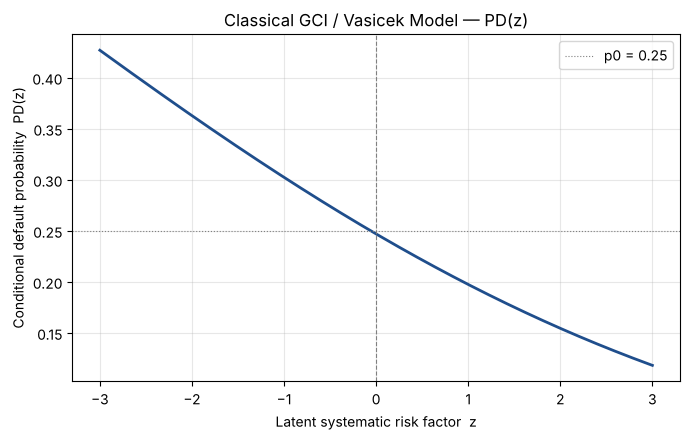

In [3]:
# ---- Visualize PD(z) across a range of the latent factor z ----
z_vals = np.linspace(-3, 3, 400)
pd_vals = pd_given_z(z_vals)

plt.figure(figsize=(7, 4.5))
plt.plot(z_vals, pd_vals, color='#1f4e8c', linewidth=2)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(p0, color='gray', linestyle=':', linewidth=0.8, label=f'p0 = {p0}')
plt.xlabel('Latent systematic risk factor  z')
plt.ylabel('Conditional default probability  PD(z)')
plt.title('Classical GCI / Vasicek Model — PD(z)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/stage01_gci_pd_curve.png', dpi=150)
plt.show()

In [4]:
def discretize_z(n_qubits, z_max=3.0):
    """Map the 2^n_qubits basis states to grid points in [-z_max, z_max],
    and assign each grid point a probability mass from the standard normal density.
    Mirrors Eq. (10) of the base paper.
    """
    n_bins = 2 ** n_qubits
    b = np.arange(n_bins)
    # affine map: basis index b -> grid point z(b) in [-z_max, z_max]
    z_grid = -z_max + (2 * z_max) * b / (n_bins - 1)

    # target probability mass function (discretized standard normal, un-normalized then normalized)
    raw = np.exp(-(z_grid ** 2) / 2)
    p_target = raw / raw.sum()
    return z_grid, p_target

for n_qubits in (2, 3):
    z_grid, p_target = discretize_z(n_qubits)
    print(f"--- {n_qubits}-qubit z-register ({2**n_qubits} bins) ---")
    for b, (zg, p) in enumerate(zip(z_grid, p_target)):
        print(f"  basis |{format(b, f'0{n_qubits}b')}>  ->  z = {zg:+.3f}   p = {p:.4f}   PD(z) = {pd_given_z(zg):.4f}")
    print()

--- 2-qubit z-register (4 bins) ---
  basis |00>  ->  z = -3.000   p = 0.0090   PD(z) = 0.4270
  basis |01>  ->  z = -1.000   p = 0.4910   PD(z) = 0.3025
  basis |10>  ->  z = +1.000   p = 0.4910   PD(z) = 0.1976
  basis |11>  ->  z = +3.000   p = 0.0090   PD(z) = 0.1183

--- 3-qubit z-register (8 bins) ---
  basis |000>  ->  z = -3.000   p = 0.0038   PD(z) = 0.4270
  basis |001>  ->  z = -2.143   p = 0.0344   PD(z) = 0.3719
  basis |010>  ->  z = -1.286   p = 0.1497   PD(z) = 0.3193
  basis |011>  ->  z = -0.429   p = 0.3121   PD(z) = 0.2701
  basis |100>  ->  z = +0.429   p = 0.3121   PD(z) = 0.2251
  basis |101>  ->  z = +1.286   p = 0.1497   PD(z) = 0.1846
  basis |110>  ->  z = +2.143   p = 0.0344   PD(z) = 0.1490
  basis |111>  ->  z = +3.000   p = 0.0038   PD(z) = 0.1183



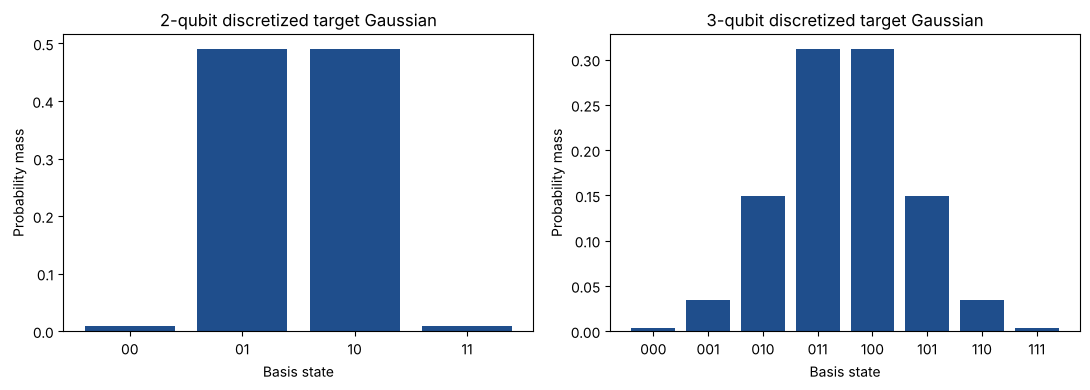

In [5]:
# ---- Plot the discretized target Gaussian histograms (2-qubit and 3-qubit) ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, n_qubits in zip(axes, (2, 3)):
    z_grid, p_target = discretize_z(n_qubits)
    labels = [format(b, f'0{n_qubits}b') for b in range(len(z_grid))]
    ax.bar(labels, p_target, color='#1f4e8c')
    ax.set_title(f'{n_qubits}-qubit discretized target Gaussian')
    ax.set_xlabel('Basis state')
    ax.set_ylabel('Probability mass')
plt.tight_layout()
plt.savefig('results/figures/stage01_gci_discretized_targets.png', dpi=150)
plt.show()

In [6]:
def classical_monte_carlo_var(p0=p0, rho=rho, lgd=1000, n_trials=2_000_000,
                               confidence=0.95, seed=42):
    """Classical Monte Carlo benchmark for the single-asset GCI model.
    Returns the loss distribution (as a PDF over unique loss values) and the VaR.
    """
    rng = np.random.default_rng(seed)
    z = rng.standard_normal(n_trials)
    pd_z = pd_given_z(z, p0=p0, rho=rho)

    u = rng.uniform(size=n_trials)
    defaulted = u < pd_z
    losses = np.where(defaulted, lgd, 0)

    unique_losses, counts = np.unique(losses, return_counts=True)
    pdf = counts / n_trials
    cdf = np.cumsum(pdf)

    var_index = np.searchsorted(cdf, confidence)
    var = unique_losses[var_index]

    return unique_losses, pdf, cdf, var

unique_losses, pdf, cdf, var_95 = classical_monte_carlo_var()

print("Classical Monte Carlo baseline (single asset, LGD = $1000, 2,000,000 trials)")
print("-" * 70)
for L, p, c in zip(unique_losses, pdf, cdf):
    print(f"  Loss = ${L:<6}  P(Loss=L) = {p:.4f}   P(Loss<=L) = {c:.4f}")
print(f"\n95% Value at Risk (VaR):  ${var_95}")

Classical Monte Carlo baseline (single asset, LGD = $1000, 2,000,000 trials)
----------------------------------------------------------------------
  Loss = $0       P(Loss=L) = 0.7497   P(Loss<=L) = 0.7497
  Loss = $1000    P(Loss=L) = 0.2503   P(Loss<=L) = 1.0000

95% Value at Risk (VaR):  $1000


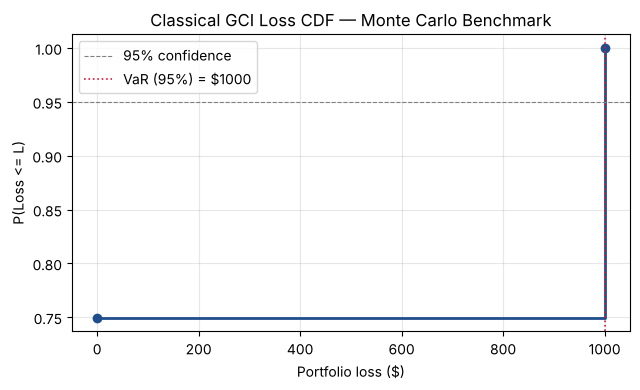

In [7]:
# ---- Plot the classical CDF, marking the 95% VaR ----
plt.figure(figsize=(6.5, 4))
plt.step(unique_losses, cdf, where='post', color='#1f4e8c', linewidth=2, marker='o')
plt.axhline(0.95, color='gray', linestyle='--', linewidth=0.8, label='95% confidence')
plt.axvline(var_95, color='crimson', linestyle=':', linewidth=1.2, label=f'VaR (95%) = ${var_95}')
plt.xlabel('Portfolio loss ($)')
plt.ylabel('P(Loss <= L)')
plt.title('Classical GCI Loss CDF — Monte Carlo Benchmark')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/stage01_gci_classical_cdf.png', dpi=150)
plt.show()

In [8]:
import json

baseline = {
    "model_parameters": {"p0": p0, "rho": rho, "lgd": 1000},
    "z_grids": {
        "2_qubit": {
            "z": discretize_z(2)[0].tolist(),
            "p_target": discretize_z(2)[1].tolist(),
        },
        "3_qubit": {
            "z": discretize_z(3)[0].tolist(),
            "p_target": discretize_z(3)[1].tolist(),
        },
    },
    "classical_monte_carlo": {
        "unique_losses": unique_losses.tolist(),
        "pdf": pdf.tolist(),
        "cdf": cdf.tolist(),
        "var_95": float(var_95),
    },
}

with open("results/classical_gci_baseline.json", "w") as f:
    json.dump(baseline, f, indent=2)

print("Saved -> results/classical_gci_baseline.json")
print(json.dumps(baseline["classical_monte_carlo"], indent=2))

Saved -> results/classical_gci_baseline.json
{
  "unique_losses": [
    0,
    1000
  ],
  "pdf": [
    0.7496935,
    0.2503065
  ],
  "cdf": [
    0.7496935,
    1.0
  ],
  "var_95": 1000.0
}
